In [1]:
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

from database import load_features
from config import CITY

df = load_features(CITY, limit=10000)

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

Dataset shape: (2184, 34)

Columns:
['id', 'timestamp', 'city', 'aqi', 'hour', 'day', 'month', 'day_of_week', 'is_weekend', 'aqi_lag_1h', 'aqi_lag_3h', 'aqi_lag_6h', 'aqi_lag_12h', 'aqi_lag_24h', 'aqi_roll_mean_3h', 'aqi_roll_mean_6h', 'aqi_roll_mean_12h', 'aqi_roll_mean_24h', 'aqi_roll_std_6h', 'aqi_roll_std_24h', 'aqi_change_1h', 'aqi_change_6h', 'aqi_change_24h', 'pm25', 'pm10', 'o3', 'no2', 'so2', 'co', 'temperature', 'humidity', 'pressure', 'wind', 'created_at']

First 5 rows:


,id,timestamp,city,aqi,hour,day,month,day_of_week,is_weekend,aqi_lag_1h,...,pm10,o3,no2,so2,co,temperature,humidity,pressure,wind,created_at
2183,2162,2026-05-28 00:00:00,karachi,73.0,0,28,5,3,0,76.0,...,36.3,45.0,12.2,5.2,178.0,28.9,91.0,1005.8,13.4,2026-08-30 23:58:09
2182,2163,2026-05-28 01:00:00,karachi,73.0,1,28,5,3,0,73.0,...,35.2,47.0,9.6,4.7,152.0,28.7,92.0,1005.3,14.3,2026-08-30 23:58:09
2181,2164,2026-05-28 02:00:00,karachi,73.0,2,28,5,3,0,73.0,...,34.3,48.0,7.5,4.3,134.0,28.4,93.0,1005.1,14.0,2026-08-30 23:58:09
2180,2165,2026-05-28 03:00:00,karachi,73.0,3,28,5,3,0,73.0,...,33.6,48.0,6.3,4.1,124.0,28.4,92.0,1004.7,14.7,2026-08-30 23:58:09
2179,2166,2026-05-28 04:00:00,karachi,73.0,4,28,5,3,0,73.0,...,32.8,49.0,5.7,4.1,123.0,28.3,92.0,1004.3,15.0,2026-08-30 23:58:09


In [2]:
# Data quality and descriptive statistics

print("=== DATA TYPES ===")
display(df.dtypes)

print("\n=== MISSING VALUES ===")
missing = df.isna().sum().sort_values(ascending=False)
display(missing[missing > 0])

print("\n=== DUPLICATE ROWS ===")
print(df.duplicated().sum())

print("\n=== DUPLICATE TIMESTAMPS ===")
print(df["timestamp"].duplicated().sum())

print("\n=== DESCRIPTIVE STATISTICS ===")
display(df.describe().T)

=== DATA TYPES ===


id                            int64
timestamp            datetime64[ns]
city                         object
aqi                         float64
hour                          int64
day                           int64
month                         int64
day_of_week                   int64
is_weekend                    int64
aqi_lag_1h                  float64
aqi_lag_3h                  float64
aqi_lag_6h                  float64
aqi_lag_12h                 float64
aqi_lag_24h                 float64
aqi_roll_mean_3h            float64
aqi_roll_mean_6h            float64
aqi_roll_mean_12h           float64
aqi_roll_mean_24h           float64
aqi_roll_std_6h             float64
aqi_roll_std_24h            float64
aqi_change_1h               float64
aqi_change_6h               float64
aqi_change_24h              float64
pm25                        float64
pm10                        float64
o3                          float64
no2                         float64
so2                         


=== MISSING VALUES ===


Series([], dtype: int64)


=== DUPLICATE ROWS ===
0

=== DUPLICATE TIMESTAMPS ===
0

=== DESCRIPTIVE STATISTICS ===


,count,mean,min,25%,50%,75%,max,std
id,2184.0,3253.5,2162.0,2707.75,3253.5,3799.25,4345.0,630.610815
timestamp,2184,2026-07-12 11:30:00,2026-05-28 00:00:00,2026-06-19 17:45:00,2026-07-12 11:30:00,2026-08-04 05:15:00,2026-08-26 23:00:00,NaN
aqi,2184.0,77.557692,61.0,72.0,76.0,83.0,109.0,8.648602
hour,2184.0,11.5,0.0,5.75,11.5,17.25,23.0,6.923772
day,2184.0,15.714286,1.0,8.0,16.0,23.0,31.0,8.826669
month,2184.0,6.868132,5.0,6.0,7.0,8.0,8.0,0.879872
day_of_week,2184.0,3.0,0.0,1.0,3.0,5.0,6.0,2.000458
is_weekend,2184.0,0.285714,0.0,0.0,0.0,1.0,1.0,0.451857
aqi_lag_1h,2184.0,77.549908,61.0,72.0,76.0,83.0,109.0,8.642345
aqi_lag_3h,2184.0,77.534341,61.0,72.0,76.0,83.0,109.0,8.629797


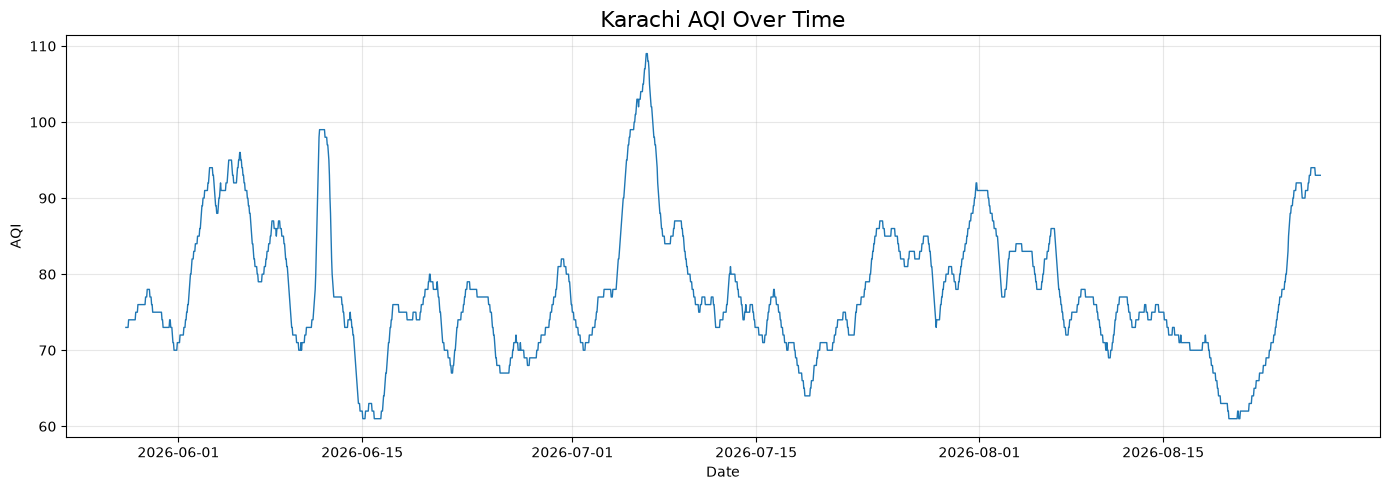

In [3]:
# AQI over time

plt.figure(figsize=(14, 5))

plt.plot(
    df["timestamp"],
    df["aqi"],
    linewidth=1
)

plt.title("Karachi AQI Over Time", fontsize=16)
plt.xlabel("Date")
plt.ylabel("AQI")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

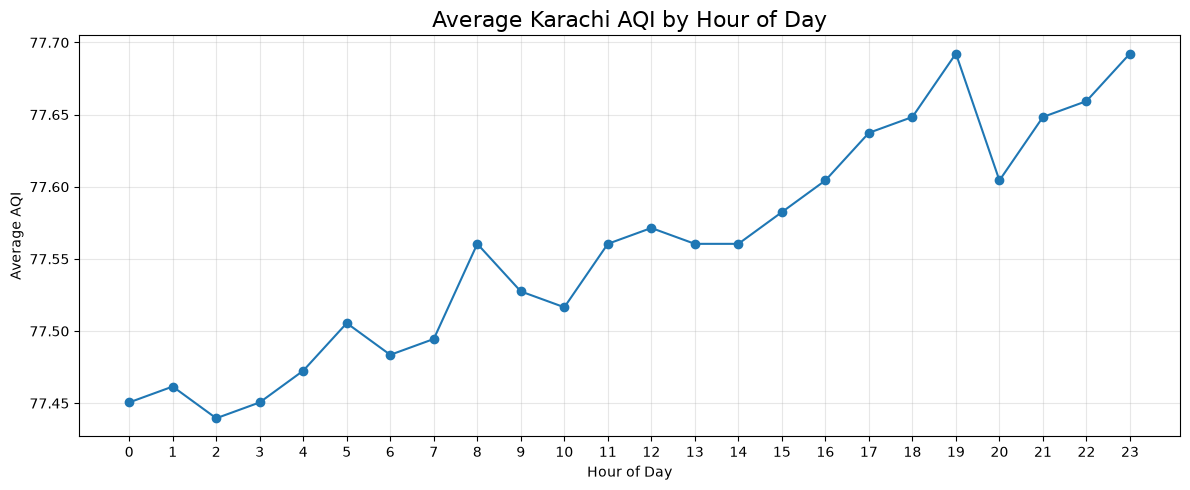

In [4]:
# Average AQI by hour of day

hourly_aqi = (
    df.groupby("hour")["aqi"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(12, 5))

plt.plot(
    hourly_aqi["hour"],
    hourly_aqi["aqi"],
    marker="o"
)

plt.title("Average Karachi AQI by Hour of Day", fontsize=16)
plt.xlabel("Hour of Day")
plt.ylabel("Average AQI")
plt.xticks(range(24))
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

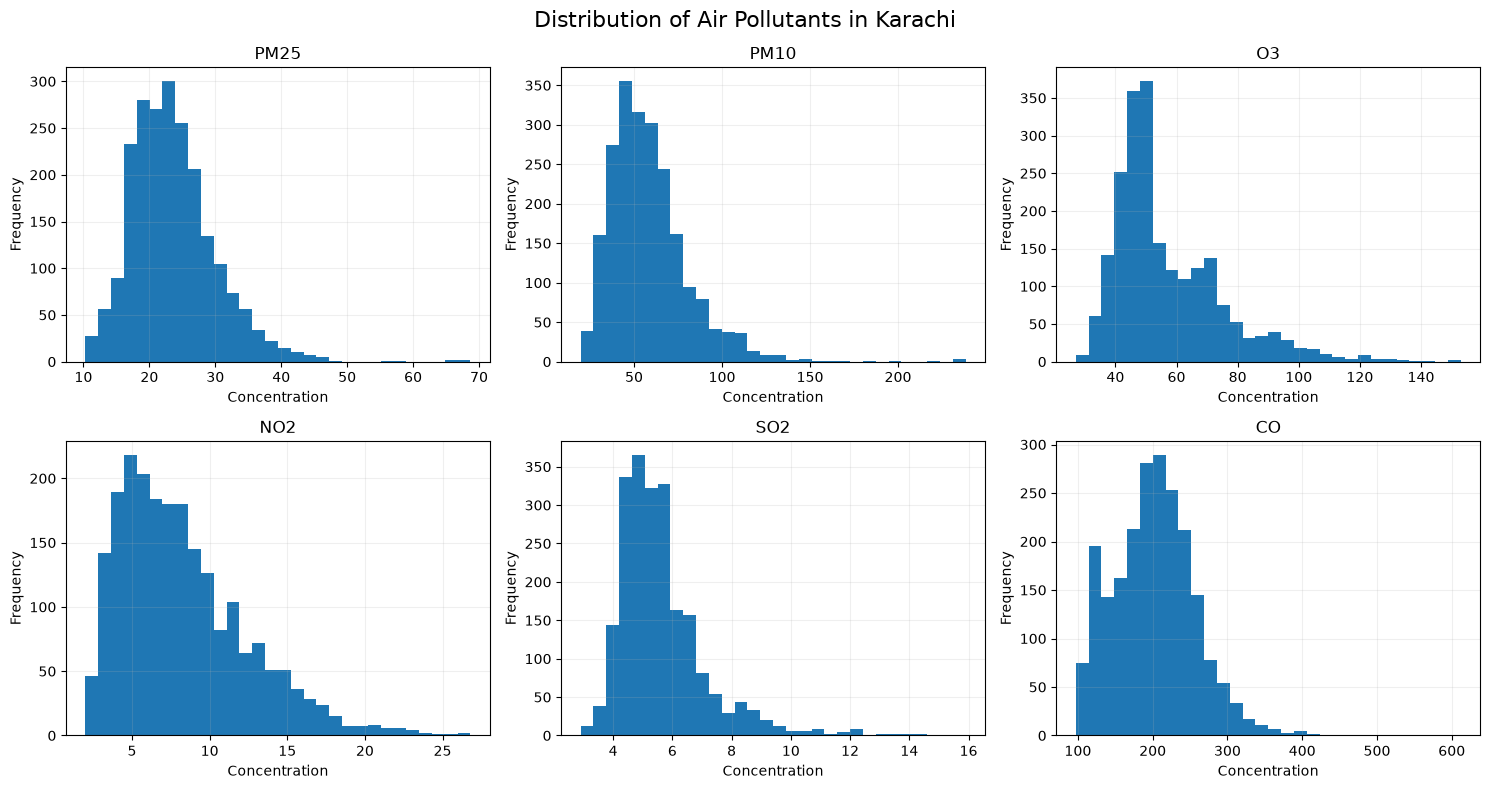

In [5]:
# Pollutant distributions

pollutants = ["pm25", "pm10", "o3", "no2", "so2", "co"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, pollutant in zip(axes.flatten(), pollutants):
    ax.hist(df[pollutant].dropna(), bins=30)
    ax.set_title(pollutant.upper())
    ax.set_xlabel("Concentration")
    ax.set_ylabel("Frequency")
    ax.grid(alpha=0.2)

plt.suptitle("Distribution of Air Pollutants in Karachi", fontsize=16)
plt.tight_layout()
plt.show()

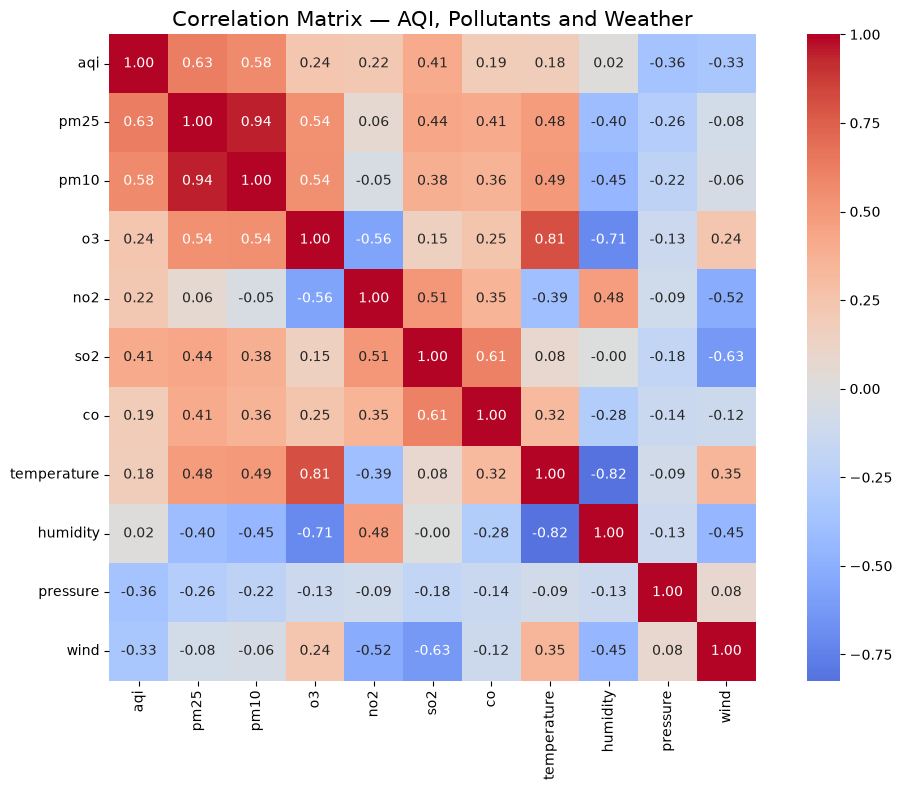

In [6]:
# Correlation of pollutants and weather variables with AQI

analysis_cols = [
    "aqi",
    "pm25",
    "pm10",
    "o3",
    "no2",
    "so2",
    "co",
    "temperature",
    "humidity",
    "pressure",
    "wind"
]

corr = df[analysis_cols].corr()

plt.figure(figsize=(11, 8))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True
)

plt.title("Correlation Matrix — AQI, Pollutants and Weather", fontsize=15)
plt.tight_layout()
plt.show()

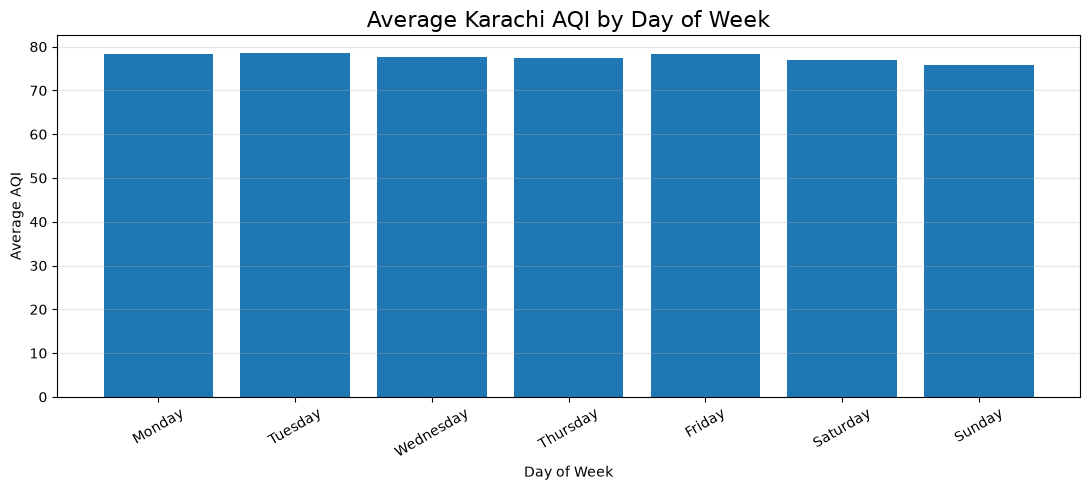


Average AQI by day:


day_name
Monday       78.266026
Tuesday      78.660256
Wednesday    77.535256
Thursday     77.355769
Friday       78.250000
Saturday     76.913462
Sunday       75.923077
Name: aqi, dtype: float64

In [7]:
# Average AQI by day of week

day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

df["day_name"] = df["timestamp"].dt.day_name()

daily_aqi = (
    df.groupby("day_name")["aqi"]
    .mean()
    .reindex(day_order)
)

plt.figure(figsize=(11, 5))

plt.bar(
    daily_aqi.index,
    daily_aqi.values
)

plt.title("Average Karachi AQI by Day of Week", fontsize=16)
plt.xlabel("Day of Week")
plt.ylabel("Average AQI")
plt.xticks(rotation=30)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

print("\nAverage AQI by day:")
display(daily_aqi)